In [1]:
using LinearAlgebra, Statistics, Random, Plots, Printf

In [2]:
function back_substitution(U, y)
    n = size(U,1)
    x = zeros(Float64, n)
    for i in n:-1:1
        s = 0.0
        for j in i+1:n
            s += U[i,j]*x[j]
        end
        x[i] = (y[i] - s) / U[i,i]
    end
    return x
end


back_substitution (generic function with 1 method)

In [3]:
# Без перестановок
function gauss_no_pivot(A, b)
    A = copy(Array{Float64}(A))
    b = copy(Array{Float64}(b))
    n = size(A,1)

    for k in 1:n-1
        for i in k+1:n
            m = A[i,k] / A[k,k]
            for j in k:n
                A[i,j] -= m*A[k,j]
            end
            b[i] -= m*b[k]
        end
    end
    return back_substitution(A, b)
end

gauss_no_pivot (generic function with 1 method)

In [4]:
# Перестановки по СТРОКАМ
function gauss_rows(A, b)
    A = copy(Array{Float64}(A))
    b = copy(Array{Float64}(b))
    n = size(A,1)

    for k in 1:n-1
        imax = argmax(abs.(A[k:n,k])) + k - 1
        if imax != k
            A[k,:], A[imax,:] = A[imax,:], A[k,:]
            b[k], b[imax] = b[imax], b[k]
        end

        for i in k+1:n
            m = A[i,k] / A[k,k]
            for j in k:n
                A[i,j] -= m*A[k,j]
            end
            b[i] -= m*b[k]
        end
    end

    return back_substitution(A, b)
end

gauss_rows (generic function with 1 method)

In [5]:
# Перестановки по СТОЛБЦАМ
function gauss_cols(A, b)
    A = copy(Array{Float64}(A))
    b = copy(Array{Float64}(b))
    n = size(A,1)

    p = collect(1:n)

    for k in 1:n-1
        jmax = argmax(abs.(A[k, k:n])) + k - 1
        if jmax != k
            A[:,[k,jmax]] = A[:,[jmax,k]]
            p[k], p[jmax] = p[jmax], p[k]
        end

        for i in k+1:n
            m = A[i,k] / A[k,k]
            for j in k:n
                A[i,j] -= m*A[k,j]
            end
            b[i] -= m*b[k]
        end
    end

    xperm = back_substitution(A, b)

    x = similar(xperm)
    for j in 1:n
        x[p[j]] = xperm[j]
    end
    return x
end

gauss_cols (generic function with 1 method)

In [6]:
# Полный выбор главного элемента
function gauss_full(A, b)
    A = copy(Array{Float64}(A))
    b = copy(Array{Float64}(b))
    n = size(A,1)

    p = collect(1:n)

    for k in 1:n-1
        imax, jmax = k, k
        maxval = 0.0
        for i in k:n
            for j in k:n
                if abs(A[i,j]) > maxval
                    maxval = abs(A[i,j])
                    imax, jmax = i, j
                end
            end
        end

        if imax != k
            A[k,:], A[imax,:] = A[imax,:], A[k,:]
            b[k], b[imax] = b[imax], b[k]
        end
        if jmax != k
            A[:,[k,jmax]] = A[:,[jmax,k]]
            p[k], p[jmax] = p[jmax], p[k]
        end

        for i in k+1:n
            m = A[i,k] / A[k,k]
            for j in k:n
                A[i,j] -= m*A[k,j]
            end
            b[i] -= m*b[k]
        end
    end

    xperm = back_substitution(A, b)

    x = similar(xperm)
    for j in 1:n
        x[p[j]] = xperm[j]
    end
    return x
end

gauss_full (generic function with 1 method)

In [7]:
function make_matrix_by_dominance(n, dom)
    R = randn(n, n)
    for i in 1:n
        R[i,i] = 0.0
    end
    rowsum = [sum(abs.(R[i, :])) for i in 1:n]
    s̄ = mean(rowsum)
    shift = (dom/12.0) * s̄

    diag = max.(rowsum .+ shift, 1e-12)

    A = copy(R)
    for i in 1:n
        A[i,i] = diag[i]
    end
    return A
end

function test_solver(solver, A, x_true)
    b = A*x_true
    x_num = solver(copy(A), copy(b))
    return norm(x_num - x_true)
end

test_solver (generic function with 1 method)

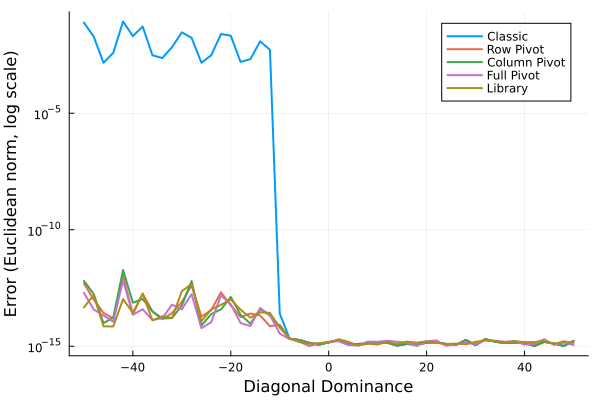

In [8]:
# Task 2
doms = collect(-50:2:50)
n = 50
# заведомо определяем значения координат вектора x
x_true = rand(n)

errs = Dict(
    "без перестановок"=>Float64[], "по строкам"=>Float64[],
    "по столбцам"=>Float64[], "строки+столбцы"=>Float64[],
    "библиотека"=>Float64[]
)
# вычисляем b путем прямого перемножения матрицы A на вектор x и далее производим поиск решения уравнения A•х = b тем или иным методом Гаусса
for d in doms
    A = make_matrix_by_dominance(n, d)
    push!(errs["без перестановок"], test_solver(gauss_no_pivot, A, x_true))
    push!(errs["по строкам"],       test_solver(gauss_rows,     A, x_true))
    push!(errs["по столбцам"],      test_solver(gauss_cols,     A, x_true))
    push!(errs["строки+столбцы"],   test_solver(gauss_full,     A, x_true))
    push!(errs["библиотека"],       test_solver((A,b)->A\b,     A, x_true))
end
# Task 4
order  = ["без перестановок","по строкам","по столбцам","строки+столбцы","библиотека"]
labels = ["Classic","Row Pivot","Column Pivot","Full Pivot","Library"]

plt = plot(
    doms, errs[order[1]],
    label = labels[1], lw=2, marker=false, grid=true,
    xlabel = "Diagonal Dominance",
    ylabel = "Error (Euclidean norm, log scale)",
    yscale = :log10,
    legend = :topright,
)
for (name,label) in zip(order[2:end], labels[2:end])
    plot!(doms, errs[name], label=label, lw=2)
end
display(plt)

In [9]:
function rounding_error(A, b, x)
    # Невязка r = Ax - b
    r = A*x - b
    r_norm = norm(r)

    # Машинное эпсилон (ошибка округления)
    ε = eps(Float64)
    
    η_A = ε
    η_b = ε
    
    μ_A = cond(A)

    #   ||δx||/||x|| ≤ μ_A * (η_A + η_b)
    est_rel = μ_A * (η_A + η_b)
    return est_rel, r_norm
end

rounding_error (generic function with 1 method)

In [10]:
# Task 6: Запрограммировать расчет погрешности возникающей при возмущении матрицы СЛАУ и правой части.
function make_perturbations_relative(A, b; η_A=1e-10, η_b=1e-10)
    ΔA_raw = rand(size(A)...) .- 0.5
    Δb_raw = rand(length(b))  .- 0.5

    #       ‖ΔA‖ = ‖ΔA_unit‖ * η_A * ‖A‖
    ΔA_unit = ΔA_raw / norm(ΔA_raw) # ‖ΔA_unit‖ = 1
    ΔA = ΔA_unit * (η_A * norm(A))
    
    #       ‖Δb‖ = ‖Δb_unit‖ * η_b * ‖b‖
    Δb_unit = Δb_raw / norm(Δb_raw) # ‖Δb_unit‖ = 1
    Δb = Δb_unit * (η_b * norm(b))

    return ΔA, Δb
end

# ||δx||/||x|| ≤ μ_A * (η_A + η_b)
function perturbation_error(A, b, x_exact, ΔA, Δb)
    #    x + Δx = x̃ = (A+ΔA)⁻¹ * (b+Δb)
    x_perturbed = (A + ΔA) \ (b + Δb)

    #    ||δx|| = ||x̃ − x||₂
    abs_err = norm(x_perturbed - x_exact)

    #    η_A = ||ΔA|| / ||A||
    η_A = norm(ΔA) / norm(A)

    #    Относительное возмущение правой(приведённой) части: η_b = ||Δb|| / ||b||
    η_b = norm(Δb) / norm(b)

    #   Число обусловленности матрицы: μ_A = ||A|| · ||A⁻¹||
    μ_A = cond(A)

    #    Теоретическая относительная граница для решения:||δx|| / ||x|| ≤ μ_A (η_A + η_b)
    bound_relative = μ_A * (η_A + η_b)

    #    Теоретическая абсолютная граница: ||δx|| ≤ μ_A (η_A + η_b) ||x||
    bound_abs = bound_relative * norm(x_exact)

    return (abs_err=abs_err,
            bound_abs=bound_abs,
            bound_rel=bound_relative)
end

perturbation_error (generic function with 1 method)

In [11]:
function show_vec(name, v; k=6)
    m = min(k, length(v))
    @printf("%s (n=%d): [", name, length(v))
    for i in 1:m
        @printf("% .6e%s", v[i], i==m ? "" : ", ")
    end
    if length(v) > k
        print(", …")
    end
    println("]")
end

function show_mat(name, A; r=5, c=6)
    n = size(A,1)
    @printf("%s (%d×%d):\n", name, n, n)
    R = min(r, n); C = min(c, n)
    for i in 1:R
        print("  [")
        for j in 1:C
            @printf("% .3e%s", A[i,j], j==C ? "" : "  ")
        end
        if n > C
            print("  …")
        end
        println("]")
    end
    if n > R
        println("  …")
    end
end

show_mat (generic function with 1 method)

In [12]:
function report(title, A, b, x_true, solver)
    x = solver(copy(A), copy(b))
    abs_err = norm(x - x_true)
    rel_err = abs_err / norm(x_true)
    round_est, rnorm = rounding_error(A,b,x)

    η_A = (0.5 + rand()) * 1e-10
    η_b = (0.5 + rand()) * 1e-10

    ΔA, Δb = make_perturbations_relative(A,b; η_A=η_A, η_b=η_b)
    pe = perturbation_error(A,b,x_true,ΔA,Δb)

    println("\n$title")
    @printf("Абсолютная погрешность: %.4e\n", abs_err)
    @printf("Относительная погрешность: %.4e\n", rel_err)
    @printf("Норма невязки: %.4e\n", rnorm)
    @printf("Погрешность округления: %.4e\n", round_est)
    @printf("Относительная граница ошибки при возмущении: %.4e\n", pe.bound_rel)
    @printf("Абсолютная граница ошибки при возмущении: %.4e\n", pe.bound_abs)
    @printf("Фактическая абс. ошибка при возмущении: %.4e\n", pe.abs_err)
end

n = 50
A = make_matrix_by_dominance(n, -15)
x_true = rand(n)
b = A*x_true

show_mat("Матрица A", A)
show_vec("Вектор x_true", x_true)
show_vec("Вектор b = A*x_true", b)

report("Метод Гаусса без перестановок",                      A,b,x_true,gauss_no_pivot)
report("Метод Гаусса с перестановками по столбцам",          A,b,x_true,gauss_cols)
report("Метод Гаусса с перестановками по строкам",           A,b,x_true,gauss_rows)
report("Метод Гаусса с перестановками по столбцам и строкам",A,b,x_true,gauss_full)
report("Библиотечный метод (Julia solve)",                   A,b,x_true,(A,b)->A\b)

Матрица A (50×50):
  [ 1.000e-12   1.013e+00   9.696e-01  -1.040e+00   9.834e-01   1.672e-02  …]
  [-4.603e-02   1.000e-12   2.702e+00   5.197e-01   1.490e+00   2.999e-01  …]
  [ 8.673e-01   4.902e-01   1.000e-12   5.595e-01   2.054e+00  -5.574e-01  …]
  [ 1.195e+00  -7.834e-01   4.912e-01   1.000e-12   1.412e+00   1.234e-01  …]
  [-1.937e-01  -2.069e-01  -1.030e-01  -3.723e-01   1.000e-12   3.807e-01  …]
  …
Вектор x_true (n=50): [ 7.024108e-01,  9.916406e-01,  7.529079e-01,  3.114878e-01,  1.904730e-01,  9.910289e-01, …]
Вектор b = A*x_true (n=50): [ 4.709597e+00, -2.097455e+00, -4.778194e+00, -9.881577e-01,  1.017323e+00, -7.157735e-01, …]

Метод Гаусса без перестановок
Абсолютная погрешность: 1.3709e-02
Относительная погрешность: 3.1730e-03
Норма невязки: 8.6673e-03
Погрешность округления: 7.5491e-14
Относительная граница ошибки при возмущении: 3.3160e-08
Абсолютная граница ошибки при возмущении: 1.4327e-07
Фактическая абс. ошибка при возмущении: 4.5330e-09

Метод Гаусса с перестан